In [6]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Skipped 36 invalid cosmologies


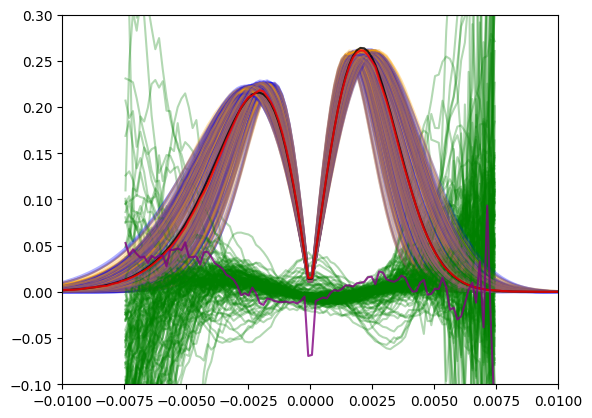

In [9]:
datafile = np.load("../data_new/cosmo_parallel_results_bin4_theta30.npz", allow_pickle=True)

data = datafile["results"]

results = data.tolist()             # convert to list of python dicts

cosmo_id = np.array([r["cosmo_id"] for r in results])

Om      = np.array([r["params"]["Om"]      for r in results])
sigma8  = np.array([r["params"]["sigma8"]  for r in results])
w_       = np.array([r["params"]["w"]       for r in results])
h       = np.array([r["params"]["h"]       for r in results])
ns      = np.array([r["params"]["ns"]      for r in results])
Ob      = np.array([r["params"]["Ob"]      for r in results])
Oc      = np.array([r["params"]["Oc"]      for r in results])
wa      = np.array([r["params"]["wa"]      for r in results])


kappa_fix = np.array([r["kappa_fix"] for r in results], dtype=object)
snr_fix   = np.array([r["snr_fix"]   for r in results], dtype=object)


theory_l1_kappa_fix = np.array([r["theory_l1_kappa_fix"] for r in results], dtype=object)
theory_l1_snr_fix   = np.array([r["theory_l1_snr_fix"]   for r in results], dtype=object)
pred_stats          = np.array([r["pred_stats"]          for r in results], dtype=object)

cg_l1_kappa_mean = np.array([r["cg_l1_kappa_mean"] for r in results])
cg_l1_snr_mean   = np.array([r["cg_l1_snr_mean"]   for r in results])

cg_variance_mean = np.array([r["cg_variance_mean"] for r in results])
cg_variance_std  = np.array([r["cg_variance_std"]  for r in results])

cg_l1_kappa_std = np.array([r["cg_l1_kappa_std"] for r in results])
cg_l1_snr_std   = np.array([r["cg_l1_snr_std"]   for r in results])

cg_l1_kappa_realizations = np.array(
    [r["cg_l1_kappa_realizations"] for r in results], dtype=object
)

cg_l1_snr_realizations = np.array(
    [r["cg_l1_snr_realizations"] for r in results], dtype=object
)

datafile = np.load("../data_new/cosmo_parallel_results_bin4_Fiducial_theta30.npz", allow_pickle=True)

data_fiducial = datafile["results"]

results_fiducial = data_fiducial.tolist()             # convert to list of python dicts

cosmo_id = np.array([r["cosmo_id"] for r in results_fiducial])
#add _fiducial to variable names
Om_fiducial      = np.array([r["params"]["Om"]      for r in results_fiducial])
sigma8_fiducial  = np.array([r["params"]["sigma8"]  for r in results_fiducial])
w_fiducial       = np.array([r["params"]["w"]       for r in results_fiducial])
h_fiducial       = np.array([r["params"]["h"]       for r in results_fiducial])
ns_fiducial      = np.array([r["params"]["ns"]      for r in results_fiducial])
Ob_fiducial      = np.array([r["params"]["Ob"]      for r in results_fiducial])
Oc_fiducial      = np.array([r["params"]["Oc"]      for r in results_fiducial])
wa_fiducial      = np.array([r["params"]["wa"]      for r in results_fiducial])


kappa_fix_fiducial = np.array([r["kappa_fix"] for r in results_fiducial], dtype=object)
snr_fix_fiducial   = np.array([r["snr_fix"]   for r in results_fiducial], dtype=object)

theory_l1_kappa_fix_fiducial = np.array([r["theory_l1_kappa_fix"] for r in results_fiducial], dtype=object)
theory_l1_snr_fix_fiducial   = np.array([r["theory_l1_snr_fix"]   for r in results_fiducial], dtype=object)
pred_stats_fiducial         = np.array([r["pred_stats"]          for r in results_fiducial], dtype=object)

cg_l1_kappa_mean_fiducial = np.array([r["cg_l1_kappa_mean"] for r in results_fiducial])
cg_l1_snr_mean_fiducial   = np.array([r["cg_l1_snr_mean"]   for r in results_fiducial])

cg_variance_mean_fiducial = np.array([r["cg_variance_mean"] for r in results_fiducial])
cg_variance_std_fiducial  = np.array([r["cg_variance_std"]  for r in results_fiducial])

cg_l1_kappa_std_fiducial = np.array([r["cg_l1_kappa_std"] for r in results_fiducial])
cg_l1_snr_std_fiducial   = np.array([r["cg_l1_snr_std"]   for r in results_fiducial])
cg_l1_kappa_realizations_fiducial = np.array([r["cg_l1_kappa_realizations"] for r in results_fiducial], dtype=object)

cg_l1_snr_realizations_fiducial = np.array(
    [r["cg_l1_snr_realizations"] for r in results_fiducial], dtype=object
)


counter = 0
for i in range(len(results)):
    if np.any(theory_l1_kappa_fix[i] <-1e-3):
        # print(f"Skipping invalid cosmology {i}")
        counter += 1
        continue
    residual = (theory_l1_kappa_fix[i] - cg_l1_kappa_mean[i])/(cg_l1_kappa_mean[i] + 1e-6)
    if np.abs(residual[230]) > 0.5:
        # print(f"Skipping invalid cosmology {i}")
        counter += 1
        continue
    plt.plot(kappa_fix[i], theory_l1_kappa_fix[i], alpha=0.3, color='blue')
    plt.plot(kappa_fix[i], cg_l1_kappa_mean[i], alpha=0.3, color='orange')
    residual = (theory_l1_kappa_fix[i] - cg_l1_kappa_mean[i])/(cg_l1_kappa_mean[i] + 1e-6)
    plt.plot(kappa_fix[i][150:250], residual[150:250], alpha=0.3, color='green')

plt.plot(kappa_fix_fiducial[0], theory_l1_kappa_fix_fiducial[0], alpha=0.8, color='black', label='Fiducial')
plt.plot(kappa_fix_fiducial[0], cg_l1_kappa_mean_fiducial[0], alpha=0.8, color='red', label='Fiducial Mean')
resid_fid = (theory_l1_kappa_fix_fiducial[0] - cg_l1_kappa_mean_fiducial[0])/(cg_l1_kappa_mean_fiducial[0] + 1e-6)
plt.plot(kappa_fix_fiducial[0][150:250], resid_fid[150:250], alpha=0.8, color='purple', label='Fiducial Residual')
plt.xlim(-0.01,0.01)
plt.ylim(-0.1,0.3)

print(f"Skipped {counter} invalid cosmologies") 


Skipped 36 invalid cosmologies


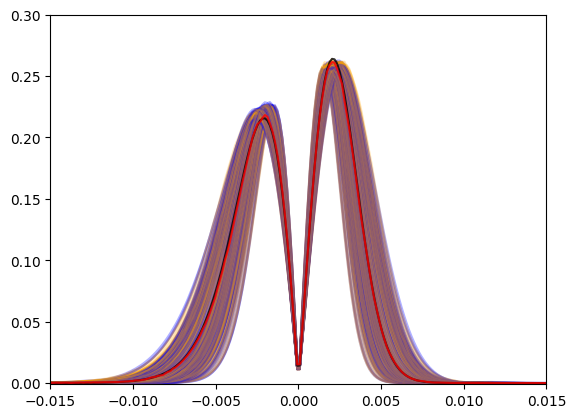

In [10]:
counter = 0
for i in range(len(results)):
    if np.any(theory_l1_kappa_fix[i] <-1e-3):
        # print(f"Skipping invalid cosmology {i}")
        counter += 1
        continue
    plt.plot(kappa_fix[i], theory_l1_kappa_fix[i], alpha=0.3, color='blue')
    plt.plot(kappa_fix[i], cg_l1_kappa_mean[i], alpha=0.3, color='orange')

plt.plot(kappa_fix_fiducial[0], theory_l1_kappa_fix_fiducial[0], alpha=0.8, color='black', label='Fiducial')
plt.plot(kappa_fix_fiducial[0], cg_l1_kappa_mean_fiducial[0], alpha=0.8, color='red', label='Fiducial Mean')
plt.xlim(-0.015,0.015)
plt.ylim(-0.001,0.3)

print(f"Skipped {counter} invalid cosmologies")

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression

# ============================================================
# 0) PARAMETERS — choose desired number of bins after rebinning
# ============================================================
new_bins = 80   # recommended: 20–40
min_var = 1e-10 # floor to avoid log(0)

# ============================================================
# 1) Rebin function
# ============================================================
def rebin(arr, new_bins):
    """
    Rebin an array (n_real, old_bins) into (n_real, new_bins)
    by block averaging.
    """
    arr = np.asarray(arr)
    n_real, old_bins = arr.shape
    factor = old_bins // new_bins
    arr = arr[:, :factor * new_bins]               # truncate extra bins
    arr_rebinned = arr.reshape(n_real, new_bins, factor).mean(axis=2)
    return arr_rebinned

# ============================================================
# 2) Build S8 and parameter array
# ============================================================
S8 = sigma8 * np.sqrt(Om / 0.3)
X_par = np.column_stack([S8, Om, w_])  # shape (n_cosmo, 3)
n_cosmo = len(X_par)

# ============================================================
# 3) Rebin all l1-kappa realizations
# ============================================================
cg_l1_kappa_rebinned = []
for arr in cg_l1_kappa_realizations:
    cg_l1_kappa_rebinned.append(rebin(arr, new_bins))
# cg_l1_kappa_rebinned = np.array(cg_l1_kappa_rebinned)  # list of (n_real, new_bins)

nbins = new_bins

# ============================================================
# 4) Covariance matrices from rebinned realizations
# ============================================================
covs_kappa = []
for arr in cg_l1_kappa_rebinned:
    C = np.cov(arr, rowvar=False)  # (nbins, nbins)
    covs_kappa.append(C)
covs_kappa = np.array(covs_kappa)  # (n_cosmo, nbins, nbins)

# ============================================================
# 5) Diagonal (variances) — clean & model
# ============================================================
diag_kappa = np.array([np.diag(C) for C in covs_kappa])  # (n_cosmo, nbins)
diag_kappa = np.where(diag_kappa <= 0, min_var, diag_kappa)

# Fit log variance to (S8, Om, w)
var_models = []
for b in range(nbins):
    y = np.log(diag_kappa[:, b])
    m = LinearRegression().fit(X_par, y)
    var_models.append(m)

def predict_variance(Om_new, sigma8_new, w_new):
    """
    Predict diagonal of covariance (variance per bin)
    """
    S8_new = sigma8_new * np.sqrt(Om_new / 0.3)
    X_new = np.array([[S8_new, Om_new, w_new]])
    logV = np.array([m.predict(X_new)[0] for m in var_models])
    return np.exp(logV)

# ============================================================
# 6) Build correlation matrices
# ============================================================
corrs_kappa = []
for C in covs_kappa:
    d = np.sqrt(np.diag(C))
    D = np.outer(d, d)
    R = C / D
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)
    R = 0.5 * (R + R.T)
    np.fill_diagonal(R, 1.0)
    corrs_kappa.append(R)
corrs_kappa = np.array(corrs_kappa)  # shape (n_cosmo, nbins, nbins)

# ============================================================
# 7) PCA decomposition in matrix space
# ============================================================
X_corr = corrs_kappa.reshape(n_cosmo, -1)
X_mean = X_corr.mean(axis=0)
X_centered = X_corr - X_mean

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

n_modes = min(3, n_cosmo, X_corr.shape[1])  # keep top ~3 modes
PCs = Vt[:n_modes]                          # shape (n_modes, nbins*nbins)

# Project onto PCs
alphas = X_centered @ PCs.T    # shape (n_cosmo, n_modes)

# Fit alphas as linear in (S8, Om, w)
alpha_models = []
for m in range(n_modes):
    y = alphas[:, m]
    mdl = LinearRegression().fit(X_par, y)
    alpha_models.append(mdl)

# ============================================================
# 8) Ensure SPD correlation matrix
# ============================================================
def to_spd_correlation(R):
    """Project matrix to SPD correlation matrix."""
    R = 0.5 * (R + R.T)
    R = np.clip(R, -0.999, 0.999)
    np.fill_diagonal(R, 1.0)

    eigvals, eigvecs = np.linalg.eigh(R)
    eigvals_clipped = np.clip(eigvals, 1e-6, None)
    R_spd = (eigvecs * eigvals_clipped) @ eigvecs.T

    d = np.sqrt(np.diag(R_spd))
    D = np.outer(d, d)
    R_corr = R_spd / D
    R_corr = 0.5 * (R_corr + R_corr.T)
    np.fill_diagonal(R_corr, 1.0)
    return R_corr

# ============================================================
# 9) Predict correlation matrix R(Om, sigma8, w)
# ============================================================
def predict_correlation(Om_new, sigma8_new, w_new):
    S8_new = sigma8_new * np.sqrt(Om_new / 0.3)
    X_new = np.array([[S8_new, Om_new, w_new]])

    alpha_new = np.array([m.predict(X_new)[0] for m in alpha_models])
    vec_R = X_mean + alpha_new @ PCs
    R = vec_R.reshape(nbins, nbins)

    return to_spd_correlation(R)

# ============================================================
# 10) Full covariance model: C = D R D
# ============================================================
def predict_covariance(Om_new, sigma8_new, w_new):
    var = predict_variance(Om_new, sigma8_new, w_new)
    R = predict_correlation(Om_new, sigma8_new, w_new)
    D = np.diag(np.sqrt(var))
    return D @ R @ D

# ============================================================
# 11) TEST at fiducial cosmology
# ============================================================
Om_fid  = Om_fiducial[0]
sig8_fid = sigma8_fiducial[0]
w_fid   = w_fiducial[0]

C_fid_model = predict_covariance(Om_fid, sig8_fid, w_fid)
print("Model covariance shape:", C_fid_model.shape)


Model covariance shape: (80, 80)


/var/folders/4z/j812r6_x1b33_hsc69yh9m240000gp/T/ipykernel_75760/4286022256.py:80: RuntimeWarning: invalid value encountered in divide
  R = C / D


the shape of sim covariance:  (80, 80)


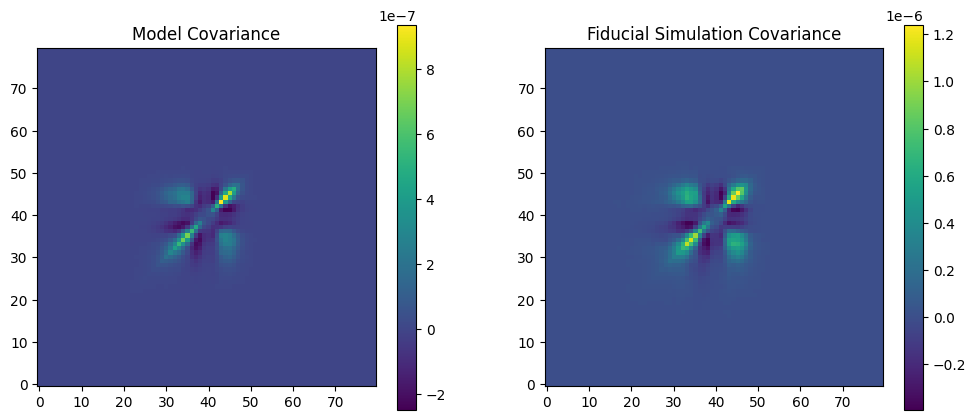

In [13]:
# Rebin fiducial
cg_l1_kappa_rebinned_fiducial = []
for arr in cg_l1_kappa_realizations_fiducial:
    cg_l1_kappa_rebinned_fiducial.append(rebin(np.asarray(arr), new_bins))

# pick the FIRST fiducial block of realizations
fid_arr = cg_l1_kappa_rebinned_fiducial  # shape (n_real, new_bins)
fid_arr = np.array(fid_arr)[0]
fid_arr = np.vstack([np.asarray(row, dtype=float) for row in fid_arr])


C_fid_sim = np.cov(fid_arr, rowvar=False)




print("the shape of sim covariance: ", C_fid_sim.shape)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Model Covariance")
plt.imshow(C_fid_model, cmap='viridis', origin='lower')
plt.colorbar()

plt.subplot(1,2,2)
plt.title("Fiducial Simulation Covariance")
plt.imshow(C_fid_sim, cmap='viridis', origin='lower')
plt.colorbar()


In [14]:
print("Any NaNs?", np.isnan(fid_arr).any())
print("Any Infs?", np.isinf(fid_arr).any())


Any NaNs? False
Any Infs? False
